In [1]:
pip install scikit-learn numpy matplotlib

LAB 8: Latency Benchmarking + Scaler Comparison

Dataset: Synthetic Sensor Data (with outliers)
Shape: (1000, 10)
Classes: [0 1]
Feature range before scaling: -44.93988317480532 to 45.847732284104154

------------------------------------------------------------
PART A: Per-Model Latency (using StandardScaler)
------------------------------------------------------------
SVM          | Accuracy: 82.00% | Avg Latency: 0.5386 ms (±0.3440)
KNN          | Accuracy: 90.00% | Avg Latency: 2.3879 ms (±0.6618)
Naive Bayes  | Accuracy: 76.33% | Avg Latency: 0.8133 ms (±1.5372)

------------------------------------------------------------
PART B: Scaler Comparison (Model = SVM)
------------------------------------------------------------
StandardScaler   Accuracy: 82.00%
MinMaxScaler     Accuracy: 81.00%
RobustScaler     Accuracy: 82.00%
Normalizer       Accuracy: 86.33%

Plot saved as lab8_results.png


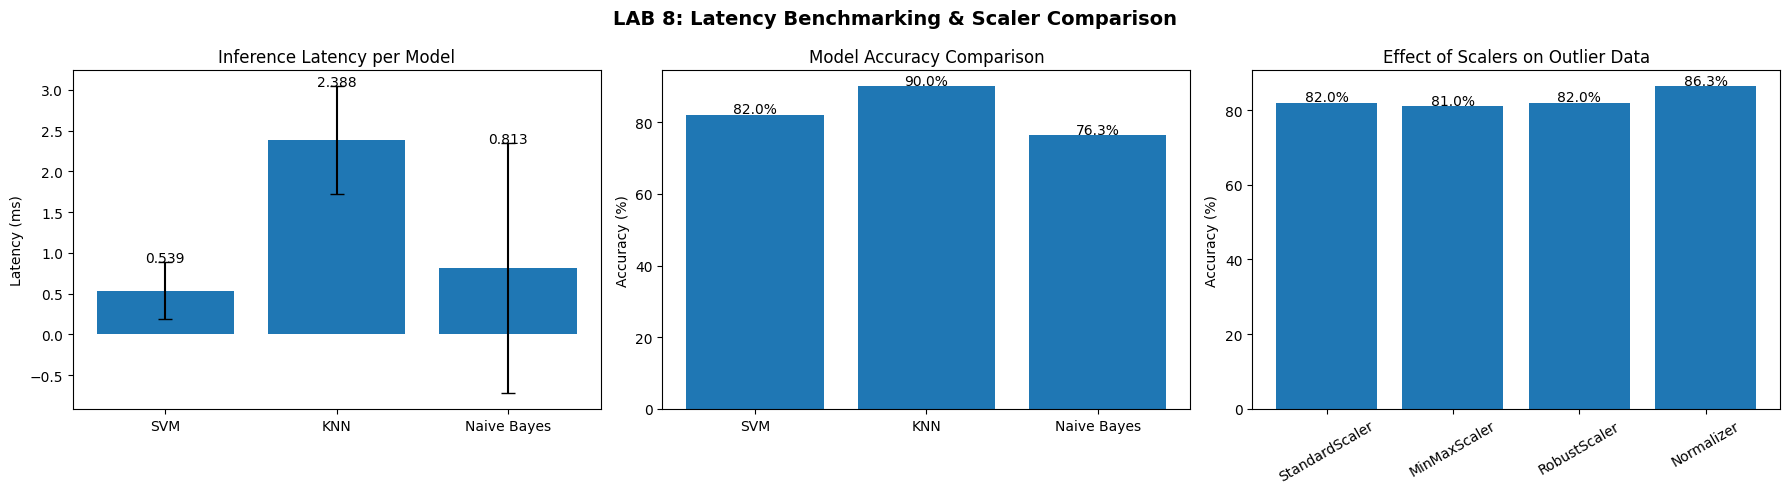


KEY INSIGHTS
1. Naive Bayes is FASTEST (no distance computation).
2. KNN is SLOWEST (computes distance to all training points).
3. RobustScaler often gives better accuracy when outliers exist.
4. MinMaxScaler can be strongly affected by outliers.
5. For edge deployment: Naive Bayes (speed) or SVM + RobustScaler.


In [2]:
# LAB 8: Latency Benchmarking + Scaler Comparison

import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.metrics import accuracy_score


print("="*60)
print("LAB 8: Latency Benchmarking + Scaler Comparison")
print("="*60)


# STEP 1: Create Dataset WITH Outliers

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

# Inject outliers (5% of data)
n_outliers = int(0.05 * len(X))
outlier_idx = np.random.choice(len(X), n_outliers, replace=False)

X[outlier_idx] += np.random.normal(0, 15, X[outlier_idx].shape)

print("\nDataset: Synthetic Sensor Data (with outliers)")
print("Shape:", X.shape)
print("Classes:", np.unique(y))
print("Feature range before scaling:", np.min(X), "to", np.max(X))


# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# STEP 2: Define Scalers and Models

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "Normalizer": Normalizer()
}

models = {
    "SVM": SVC(kernel="rbf", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}


# STEP 3: Benchmark — Latency per Model

def measure_latency(model, X_test_scaled, n_runs=100):

    latencies = []

    for _ in range(n_runs):
        sample = X_test_scaled[np.random.randint(0, len(X_test_scaled))].reshape(1, -1)

        t0 = time.perf_counter()
        model.predict(sample)
        latency = (time.perf_counter() - t0) * 1000

        latencies.append(latency)

    return np.mean(latencies), np.std(latencies)


print("\n" + "-"*60)
print("PART A: Per-Model Latency (using StandardScaler)")
print("-"*60)


scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

latency_results = {}
accuracy_results = {}

for name, model in models.items():

    model.fit(X_train_std, y_train)

    y_pred = model.predict(X_test_std)
    acc = accuracy_score(y_test, y_pred)

    mean_lat, std_lat = measure_latency(model, X_test_std)

    latency_results[name] = (mean_lat, std_lat)
    accuracy_results[name] = acc

    print(
        f"{name:<12} | Accuracy: {acc*100:.2f}% | "
        f"Avg Latency: {mean_lat:.4f} ms (±{std_lat:.4f})"
    )


# STEP 4: Scaler Comparison on Outlier Data

print("\n" + "-"*60)
print("PART B: Scaler Comparison (Model = SVM)")
print("-"*60)

scaler_accuracy = {}

for scaler_name, scaler_obj in scalers.items():

    X_tr = scaler_obj.fit_transform(X_train)
    X_te = scaler_obj.transform(X_test)

    svm = SVC(kernel="rbf", random_state=42)

    svm.fit(X_tr, y_train)

    y_pred = svm.predict(X_te)

    acc = accuracy_score(y_test, y_pred)

    scaler_accuracy[scaler_name] = acc

    print(f"{scaler_name:<16} Accuracy: {acc*100:.2f}%")


# STEP 5: Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("LAB 8: Latency Benchmarking & Scaler Comparison", fontsize=14, fontweight="bold")


# Plot 1: Latency per model

model_names = list(latency_results.keys())
means = [latency_results[m][0] for m in model_names]
stds = [latency_results[m][1] for m in model_names]

axes[0].bar(model_names, means, yerr=stds, capsize=5)

axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Inference Latency per Model")

for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.001, f"{m:.3f}", ha="center")


# Plot 2: Accuracy per model

accs = [accuracy_results[m] * 100 for m in model_names]

axes[1].bar(model_names, accs)

axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Model Accuracy Comparison")

for i, a in enumerate(accs):
    axes[1].text(i, a + 0.5, f"{a:.1f}%", ha="center")


# Plot 3: Scaler comparison

sc_names = list(scaler_accuracy.keys())
sc_accs = [scaler_accuracy[s] * 100 for s in sc_names]

axes[2].bar(sc_names, sc_accs)

axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Effect of Scalers on Outlier Data")
axes[2].tick_params(axis="x", rotation=30)

for i, a in enumerate(sc_accs):
    axes[2].text(i, a + 0.5, f"{a:.1f}%", ha="center")


plt.tight_layout()
plt.savefig("lab8_results.png", dpi=150)
print("\nPlot saved as lab8_results.png")

plt.show()


# STEP 6: Key Insight Summary

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

print("1. Naive Bayes is FASTEST (no distance computation).")
print("2. KNN is SLOWEST (computes distance to all training points).")
print("3. RobustScaler often gives better accuracy when outliers exist.")
print("4. MinMaxScaler can be strongly affected by outliers.")
print("5. For edge deployment: Naive Bayes (speed) or SVM + RobustScaler.")